<a href="https://colab.research.google.com/github/leman-cap13/DL_projects/blob/main/Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision albumentations opencv-python tqdm scikit-learn

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"lmanqasml","key":"2d851a4eb9cae06770577185722326e0"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d debeshjha1/kvasirseg -p ./data
!unzip -q ./data/kvasirseg.zip -d ./data/kvasirseg

Dataset URL: https://www.kaggle.com/datasets/debeshjha1/kvasirseg
License(s): copyright-authors
100% 144M/144M [00:08<00:00, 17.2MB/s]



In [20]:
import os
import cv2
import numpy as np
from glob import glob
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

In [5]:
DATA_DIR = "./data/kvasirseg/Kvasir-SEG/Kvasir-SEG"
IMAGE_DIR = os.path.join(DATA_DIR, "images")
MASK_DIR = os.path.join(DATA_DIR, "masks")

image_paths = sorted(glob(os.path.join(IMAGE_DIR, "*")))

mask_paths = sorted(glob(os.path.join(MASK_DIR, "*")))

In [6]:
train_images, val_images, train_masks, val_masks = train_test_split(
    image_paths,
    mask_paths,
    test_size=0.2,
    random_state=42,
)

In [7]:
train_transform = A.Compose([
        A.Resize(128,128),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.2),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.05,
            scale_limit=0.1,
            rotate_limit=15,
            p=0.5,
        ),
        A.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225),
        ),
        ToTensorV2(),
    ])

val_transform = A.Compose([
        A.Resize(128,128),
        A.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225),
        ),
        ToTensorV2(),
    ])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [8]:
class MedicalSegmentationDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)

        mask = (mask > 127).astype("float32")

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        mask = mask.unsqueeze(0)

        return image, mask

In [9]:
train_dataset = MedicalSegmentationDataset(
        train_images,
        train_masks,
        transform=train_transform,
    )

val_dataset = MedicalSegmentationDataset(
    val_images,
    val_masks,
    transform=val_transform,
)

In [10]:
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

In [11]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

In [12]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()

        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Encoder
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # Decoder
        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2)
            )
            self.ups.append(DoubleConv(feature * 2, feature))

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip = skip_connections[idx // 2]

            if x.shape != skip.shape:
                x = torch.nn.functional.interpolate(
                    x,
                    size=skip.shape[2:],
                    mode="bilinear",
                    align_corners=False,
                )

            x = torch.cat((skip, x), dim=1)
            x = self.ups[idx + 1](x)

        return self.final_conv(x)

In [13]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        probs = probs.view(-1)
        targets = targets.view(-1)

        intersection = (probs * targets).sum()
        dice = (2.0 * intersection + self.smooth) / (
            probs.sum() + targets.sum() + self.smooth
        )

        return 1.0 - dice

In [14]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.8, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction="none")

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        probs = torch.sigmoid(logits)

        pt = torch.where(targets == 1, probs, 1 - probs)
        focal_weight = self.alpha * (1 - pt) ** self.gamma

        return (focal_weight * bce_loss).mean()

In [15]:
class DiceFocalLoss(nn.Module):
    def __init__(self, dice_weight=0.5, focal_weight=0.5):
        super().__init__()
        self.dice = DiceLoss()
        self.focal = FocalLoss()
        self.dice_weight = dice_weight
        self.focal_weight = focal_weight

    def forward(self, logits, targets):
        return (
            self.dice_weight * self.dice(logits, targets)
            + self.focal_weight * self.focal(logits, targets)
        )

In [16]:
def dice_score(logits, targets, threshold=0.5, smooth=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds = preds.view(-1)
    targets = targets.view(-1)

    intersection = (preds * targets).sum()

    dice = (2.0 * intersection + smooth) / (
        preds.sum() + targets.sum() + smooth
    )

    return dice.item()

In [17]:
def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()

    total_loss = 0.0
    total_dice = 0.0

    for images, masks in tqdm(loader):
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        loss = loss_fn(logits, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_dice += dice_score(logits.detach(), masks)

    return total_loss / len(loader), total_dice / len(loader)


def validate(model, loader, loss_fn, device):
    model.eval()

    total_loss = 0.0
    total_dice = 0.0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            loss = loss_fn(logits, masks)

            total_loss += loss.item()
            total_dice += dice_score(logits, masks)

    return total_loss / len(loader), total_dice / len(loader)

In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNet(in_channels=3, out_channels=1, features=[16, 32, 64]).to(device)

loss_fn = DiceFocalLoss(dice_weight=0.5, focal_weight=0.5)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4,
)

In [30]:
best_dice = 0.0
epochs = 20

for epoch in range(epochs):
    train_loss, train_dice = train_one_epoch(
        model,
        train_loader,
        optimizer,
        loss_fn,
        device,
    )

    val_loss, val_dice = validate(
        model,
        val_loader,
        loss_fn,
        device,
    )

    print(
        f"Epoch [{epoch + 1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Dice: {train_dice:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Dice: {val_dice:.4f}"
    )

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), "best_unet_kvasir_seg.pth")
        print(f"Saved best model with Dice: {best_dice:.4f}")


100%|██████████| 400/400 [00:07<00:00, 51.53it/s]


Epoch [1/20] Train Loss: 0.2546 Train Dice: 0.6971 Val Loss: 0.2422 Val Dice: 0.7129
Saved best model with Dice: 0.7129


100%|██████████| 400/400 [00:06<00:00, 57.15it/s]


Epoch [2/20] Train Loss: 0.2470 Train Dice: 0.7062 Val Loss: 0.2437 Val Dice: 0.7060


100%|██████████| 400/400 [00:07<00:00, 52.94it/s]


...

Epoch [18/20] Train Loss: 0.1948 Train Dice: 0.7717 Val Loss: 0.1972 Val Dice: 0.7705
Saved best model with Dice: 0.7705


100%|██████████| 400/400 [00:07<00:00, 51.96it/s]


Epoch [19/20] Train Loss: 0.1875 Train Dice: 0.7794 Val Loss: 0.1993 Val Dice: 0.7677


100%|██████████| 400/400 [00:07<00:00, 52.55it/s]


Epoch [20/20] Train Loss: 0.1899 Train Dice: 0.7756 Val Loss: 0.2129 Val Dice: 0.7400


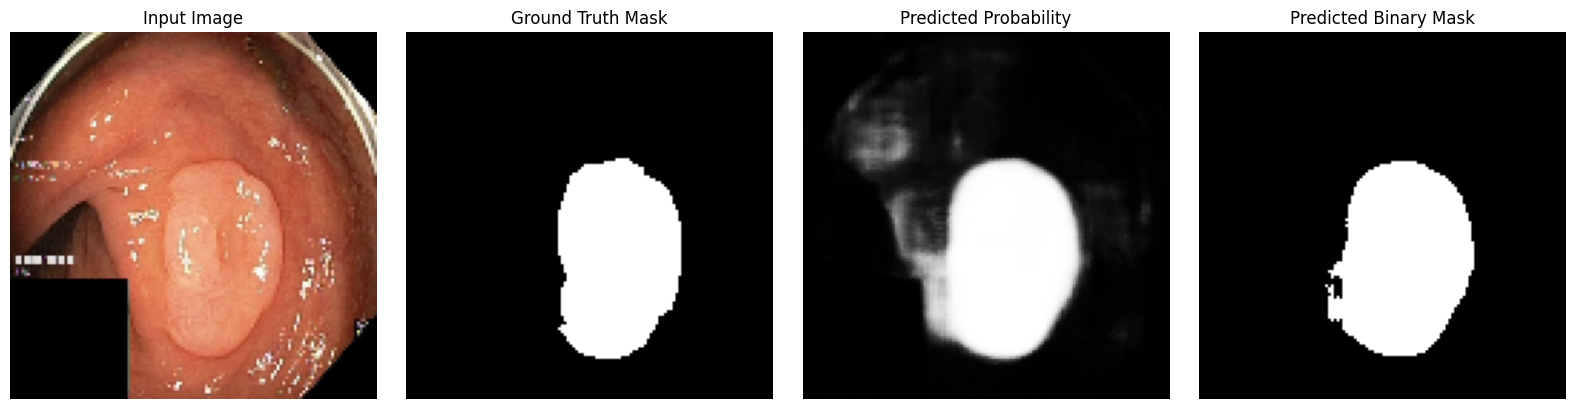

In [31]:
model.load_state_dict(torch.load("best_unet_kvasir_seg.pth", map_location=device))
model.eval()

image, mask = val_dataset[0]

with torch.no_grad():
    logits = model(image.unsqueeze(0).to(device))   # [1, C, H, W]
    prob = torch.sigmoid(logits)
    pred = (prob > 0.8).float()

image_np = image.permute(1, 2, 0).cpu().numpy()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

image_np = image_np * std + mean
image_np = np.clip(image_np, 0, 1)

mask_np = mask.squeeze().cpu().numpy()
pred_np = pred.squeeze().cpu().numpy()
prob_np = prob.squeeze().cpu().numpy()

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.title("Input Image")
plt.imshow(image_np)
plt.axis("off")

plt.subplot(1, 4, 2)
plt.title("Ground Truth Mask")
plt.imshow(mask_np, cmap="gray")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.title("Predicted Probability")
plt.imshow(prob_np, cmap="gray")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.title("Predicted Binary Mask")
plt.imshow(pred_np, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

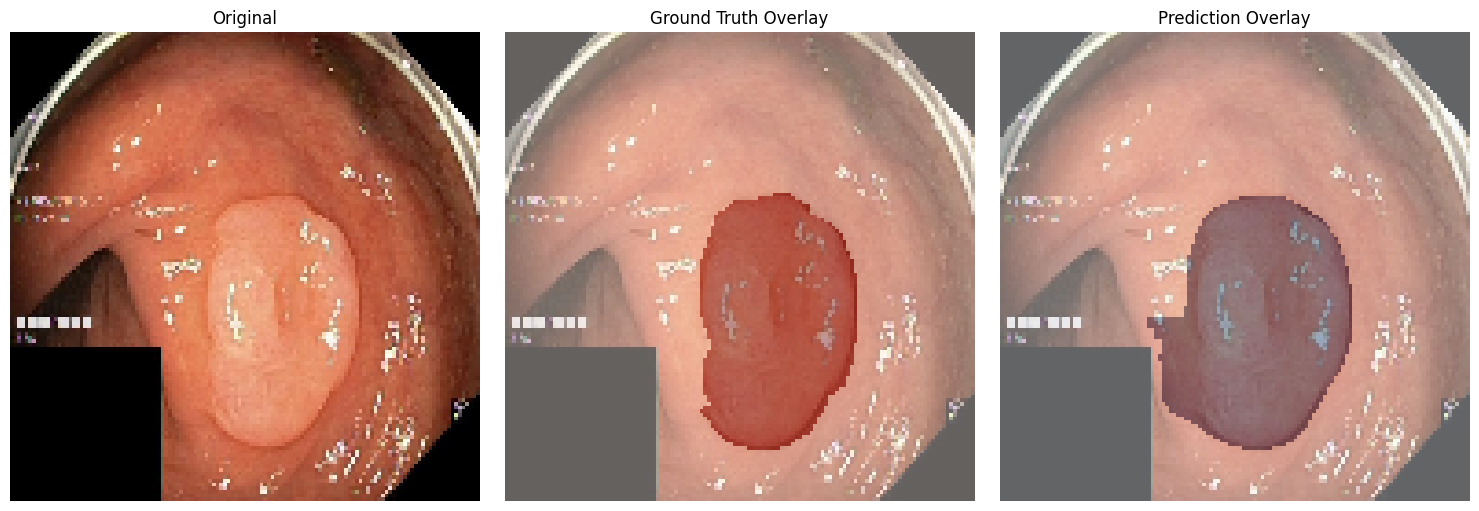

In [32]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(image_np)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Ground Truth Overlay")
plt.imshow(image_np)
plt.imshow(mask_np, cmap="Reds", alpha=0.4)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Prediction Overlay")
plt.imshow(image_np)
plt.imshow((prob_np > 0.65), cmap="Blues", alpha=0.4)
plt.axis("off")

plt.tight_layout()
plt.show()

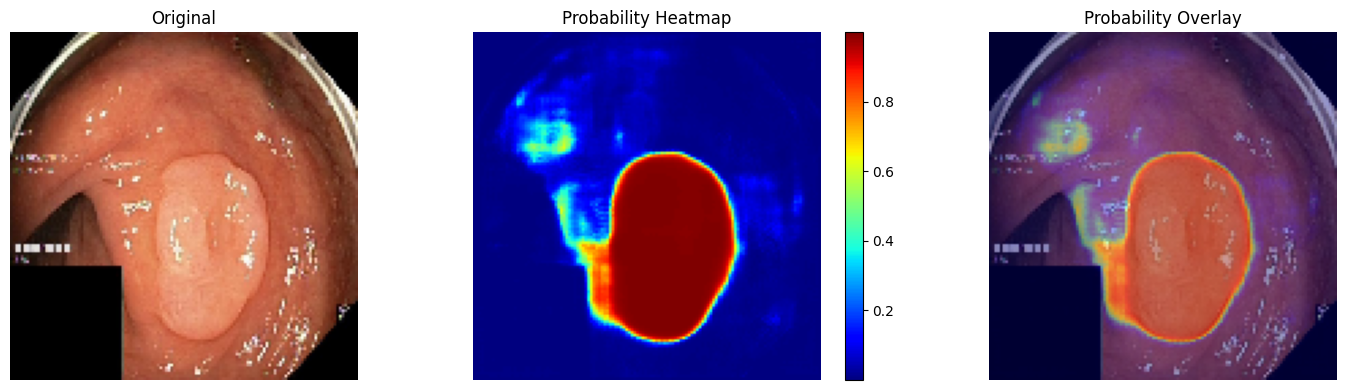

In [33]:
prob_np = prob.squeeze().cpu().numpy()

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(image_np)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(prob_np, cmap="jet")
plt.title("Probability Heatmap")
plt.axis("off")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(image_np)
plt.imshow(prob_np, cmap="jet", alpha=0.4)
plt.title("Probability Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

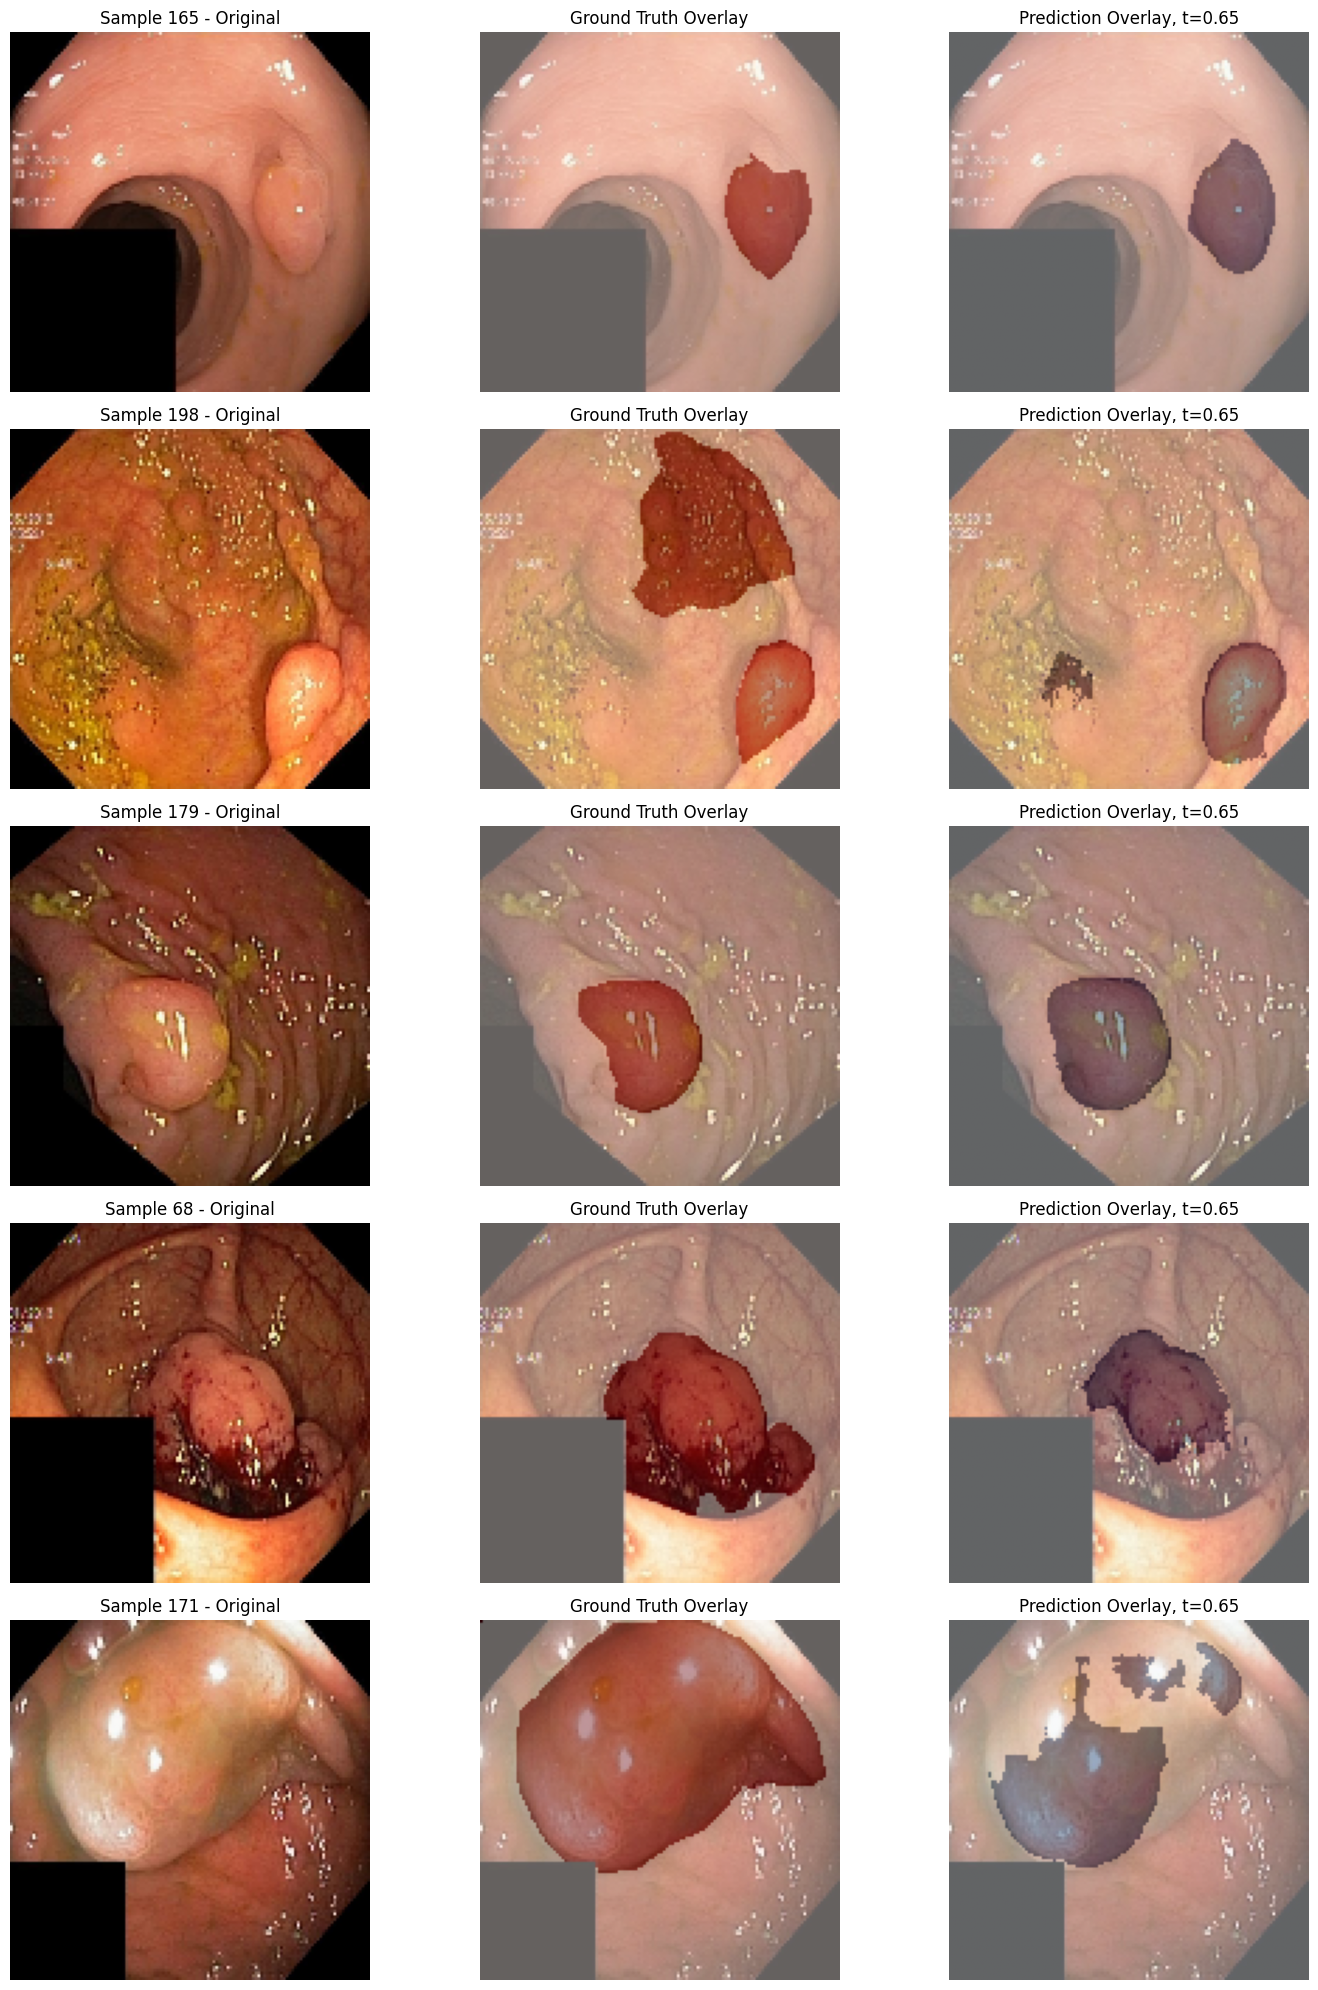

In [34]:
import random
import torch
import numpy as np
import matplotlib.pyplot as plt

model.load_state_dict(torch.load("best_unet_kvasir_seg.pth", map_location=device))
model.eval()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

threshold = 0.65

indices = random.sample(range(len(val_dataset)), 5)

plt.figure(figsize=(15, 20))

for row, idx in enumerate(indices):
    image, mask = val_dataset[idx]

    with torch.no_grad():
        logits = model(image.unsqueeze(0).to(device))
        prob = torch.sigmoid(logits)
        pred = (prob > threshold).float()

    # Image denormalize
    image_np = image.permute(1, 2, 0).cpu().numpy()
    image_np = image_np * std + mean
    image_np = np.clip(image_np, 0, 1)

    mask_np = mask.squeeze().cpu().numpy()
    pred_np = pred.squeeze().cpu().numpy()

    #  Original
    plt.subplot(5, 3, row * 3 + 1)
    plt.imshow(image_np)
    plt.title(f"Sample {idx} - Original")
    plt.axis("off")

    #  Ground Truth Overlay
    plt.subplot(5, 3, row * 3 + 2)
    plt.imshow(image_np)
    plt.imshow(mask_np, cmap="Reds", alpha=0.4)
    plt.title("Ground Truth Overlay")
    plt.axis("off")

    #  Prediction Overlay
    plt.subplot(5, 3, row * 3 + 3)
    plt.imshow(image_np)
    plt.imshow(pred_np, cmap="Blues", alpha=0.4)
    plt.title(f"Prediction Overlay, t={threshold}")
    plt.axis("off")

plt.tight_layout()
plt.show()